# Search Results Analysis

This notebook analyzes hyperparameter search results from epoch_scores.txt files.

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import json

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [ ]:
# Parse epoch_scores.txt (CSV format)
def parse_epoch_scores(file_path):
    try:
        df = pd.read_csv(file_path)
        if not df.empty and 'epoch' in df.columns:
            return df
    except:
        pass
    return pd.DataFrame()
# Extract model info from path
def extract_model_info(file_path):
    path = Path(file_path)
    exp_dir = path.parent
    search_dir = exp_dir.parent
    dir_name = search_dir.name
    
    info = {
        'search_dir': str(search_dir),
        'exp_dir': str(exp_dir.name),
        'dir_name': dir_name,
        'model_type': 'unknown',
        'sequence_length': 'unknown',
        'feature_num': 'unknown',
    }
    
    parts = dir_name.split('_')
    if len(parts) >= 2:
        info['model_type'] = parts[1]
    else:
        model_types = ['itransformer', 'transformer', 'lstm', 'tcn', 'gru']
        for mt in model_types:
            if mt in dir_name.lower():
                info['model_type'] = mt
                break
    
    for part in parts:
        if part.isdigit() and 10 <= int(part) <= 200:
            info['sequence_length'] = int(part)
            break
    
    # Check from longest to shortest to avoid '39' matching before '158+39+97'
    feature_nums = ['158+39+97', '158+39', '39+97', '158+97', '97', '39']
    for fn in feature_nums:
        if fn in dir_name:
            info['feature_num'] = fn
            break
    return info

# ETF

In [33]:

base_dir = "../etf_model"

# 找到所有 search_*_74 文件夹
search_dirs = glob.glob(f"{base_dir}/search_*_74")

score_files = glob.glob(os.path.join(base_dir, "search_*_74_3", "exp_*", "epoch_scores.txt"), recursive=True)

print(f"找到 {len(score_files)} 个 epoch_scores.txt 文件")


找到 0 个 epoch_scores.txt 文件


In [ ]:
os.path.join(base_dir, "search_*_74_3", "exp_*", "epoch_scores.txt")

'../etf_model/search_*_74_3/exp_*/epoch_scores.txt'

In [32]:
# Load all results
all_results = []

for score_file in score_files:
    df_scores = parse_epoch_scores(score_file)
    if df_scores.empty:
        continue
    
    model_info = extract_model_info(score_file)
    for key, value in model_info.items():
        df_scores[key] = value
    
    df_scores['score_file'] = score_file
    all_results.append(df_scores)

if all_results:
    combined_df = pd.concat(all_results, ignore_index=True)
    print(f"Loaded {len(combined_df)} epoch records from {len(all_results)} experiments")
    print(f"Columns: {list(combined_df.columns)}")
else:
    print("No epoch scores found")
    combined_df = pd.DataFrame()

Loaded 5042 epoch records from 169 experiments
Columns: ['epoch', 'weekly_score', 'sliding_score', 'train_loss', 'eval_loss', 'eval_sliding_loss', 'lr', 'epoch_time_sec', 'weekly_pred_return_sum', 'weekly_max_return_sum', 'weekly_random_return_sum', 'weekly_excess_return', 'weekly_hit_rate', 'weekly_proximity_score', 'weekly_rank_ic', 'weekly_precision', 'weekly_recall', 'weekly_mrr', 'weekly_ndcg', 'weekly_std_pred_return', 'weekly_std_final_score', 'sliding_pred_return_sum', 'sliding_max_return_sum', 'sliding_random_return_sum', 'sliding_excess_return', 'sliding_hit_rate', 'sliding_proximity_score', 'sliding_rank_ic', 'sliding_precision', 'sliding_recall', 'sliding_mrr', 'sliding_ndcg', 'sliding_std_pred_return', 'sliding_std_final_score', 'search_dir', 'exp_dir', 'dir_name', 'model_type', 'sequence_length', 'feature_num', 'score_file']


In [22]:
base_cols = ['model_type', 'exp_dir', 'epoch']
score_cols = ['weekly_score',  'weekly_pred_return_sum', 'weekly_excess_return',
              'weekly_hit_rate', 'weekly_proximity_score', 'weekly_rank_ic',
              'weekly_precision', 'weekly_recall', 'weekly_mrr','weekly_ndcg',  
              
              'sliding_score','sliding_pred_return_sum', 'sliding_excess_return',
              'sliding_hit_rate', 'sliding_proximity_score', 'sliding_rank_ic',
              'sliding_precision', 'sliding_recall', 'sliding_mrr', 'sliding_ndcg']
cols = base_cols + score_cols
pd.DataFrame(combined_df[score_cols].max()).T

,weekly_score,weekly_pred_return_sum,weekly_excess_return,weekly_hit_rate,weekly_proximity_score,weekly_rank_ic,weekly_precision,weekly_recall,weekly_mrr,weekly_ndcg,sliding_score,sliding_pred_return_sum,sliding_excess_return,sliding_hit_rate,sliding_proximity_score,sliding_rank_ic,sliding_precision,sliding_recall,sliding_mrr,sliding_ndcg
0,0.268683,0.07371,0.114712,0.183333,0.62908,0.131946,0.616667,0.141391,0.933333,0.153568,0.210633,0.063527,0.100183,0.2,0.586111,0.101698,0.529167,0.10457,0.790832,0.136648


/home/linuxyl/THU-BDC2026/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.draw()


<Axes: >

/home/linuxyl/THU-BDC2026/.venv/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  func(*args, **kwargs)
/home/linuxyl/THU-BDC2026/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


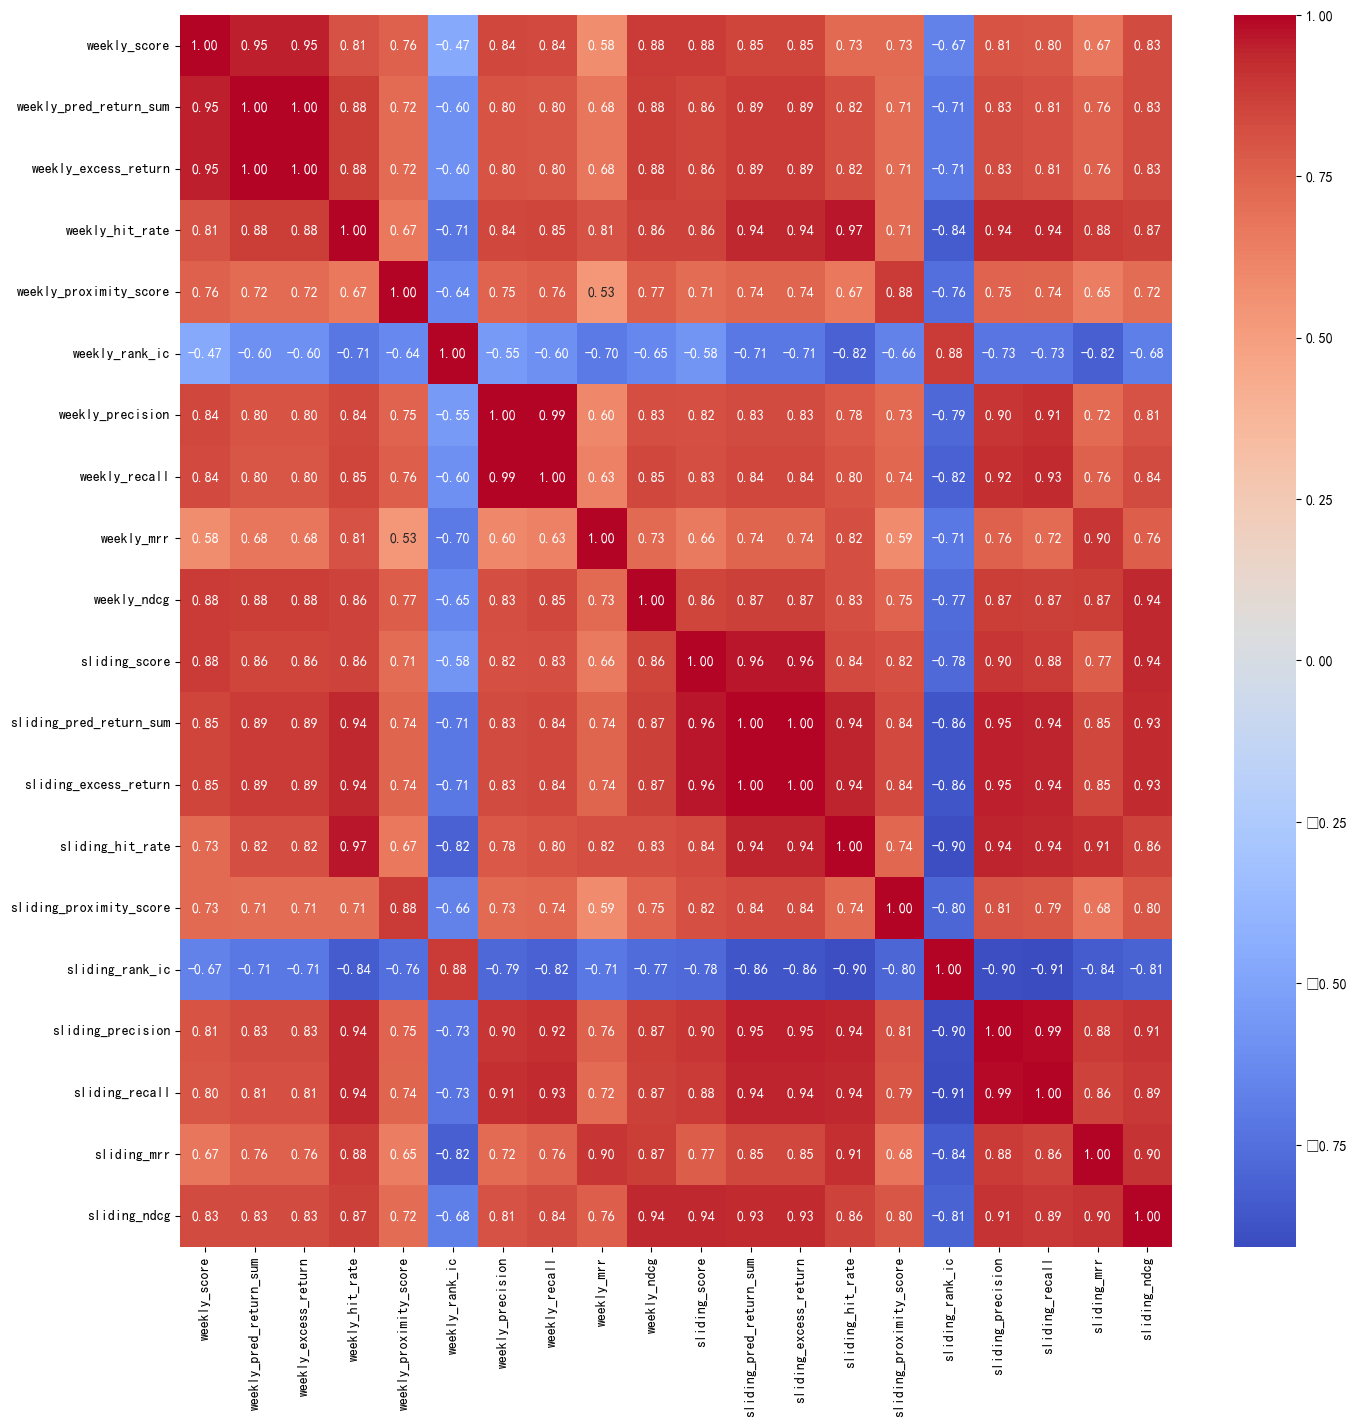

In [23]:
fig, axes = plt.subplots(1, 1, figsize=(16, 16))
sns.heatmap(combined_df[score_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")

In [8]:
combined_df.sort_values(by=["weekly_pred_return_sum"], ascending=False)[cols].head(10) 

,model_type,exp_dir,epoch,weekly_score,weekly_pred_return_sum,weekly_excess_return,weekly_hit_rate,weekly_proximity_score,weekly_rank_ic,weekly_precision,weekly_recall,weekly_mrr,weekly_ndcg,sliding_score,sliding_pred_return_sum,sliding_excess_return,sliding_hit_rate,sliding_proximity_score,sliding_rank_ic,sliding_precision,sliding_recall,sliding_mrr,sliding_ndcg
4064,tcn,exp_18,15,0.443147,0.118527,0.159529,0.316667,0.662990,0.076538,0.716667,0.169819,0.847222,0.307538,0.233989,0.061528,0.098183,0.245833,0.549708,0.034845,0.533333,0.119064,0.754033,0.128762
3609,tcn,exp_34,10,0.380704,0.095741,0.136743,0.333333,0.627377,0.074637,0.533333,0.118785,0.850000,0.242131,0.254510,0.073076,0.109731,0.183333,0.585855,0.004878,0.545833,0.102495,0.741667,0.148211
4131,tcn,exp_14,22,0.404063,0.089811,0.130813,0.316667,0.652208,0.136664,0.683333,0.157242,0.937500,0.339534,0.258982,0.082690,0.119345,0.283333,0.577136,0.073988,0.558333,0.129952,0.807639,0.215796
3827,tcn,exp_35,18,0.309937,0.088852,0.129854,0.183333,0.629667,0.073989,0.433333,0.090349,0.618056,0.049404,0.242156,0.082557,0.119212,0.195833,0.593055,0.018598,0.450000,0.096757,0.640625,0.038778
2647,tcn,exp_55,8,0.323053,0.086667,0.127669,0.233333,0.664633,0.164860,0.550000,0.115770,0.772222,0.156124,0.185626,0.071044,0.107699,0.237500,0.593228,0.066689,0.512500,0.109045,0.687509,0.012741
3718,tcn,exp_39,29,0.410400,0.085914,0.126916,0.250000,0.640269,0.105518,0.650000,0.151495,0.881944,0.332823,0.304579,0.100860,0.137516,0.258333,0.598524,0.012380,0.550000,0.132099,0.777976,0.257737
4137,tcn,exp_14,28,0.428589,0.085179,0.126181,0.316667,0.665371,0.129306,0.700000,0.167005,0.766667,0.278731,0.280726,0.085302,0.121958,0.270833,0.598913,0.069673,0.566667,0.130310,0.757837,0.191245
3887,tcn,exp_42,18,0.386276,0.084846,0.125848,0.216667,0.675553,0.168308,0.616667,0.130164,0.729167,0.171664,0.356535,0.117489,0.154145,0.237500,0.637152,0.090743,0.558333,0.129069,0.781250,0.222275
2788,tcn,exp_19,29,0.338000,0.084090,0.125092,0.300000,0.644181,0.119842,0.700000,0.164611,0.819444,0.108648,0.107161,0.035470,0.072125,0.245833,0.531817,0.036964,0.512500,0.111111,0.706408,-0.091619
3710,tcn,exp_39,21,0.410112,0.083999,0.125001,0.233333,0.647821,0.091954,0.700000,0.167738,0.933333,0.371434,0.227005,0.058102,0.094758,0.220833,0.552238,0.005581,0.512500,0.123840,0.788889,0.206203


## TCN

In [26]:
import os
import json
import pandas as pd
import glob

base_dir = "../etf_model"
model_types = ['tcn', 'itransformer', 'timesnet','dlinear']

results_list = []

for model_type in model_types:
    score_files = glob.glob(os.path.join(base_dir, f"search_{model_type}_74", "exp_*", "epoch_scores.txt"))
    print(f"找到 {len(score_files)} 个{model_type}实验结果")
    
    for score_file in score_files:
        exp_dir = os.path.dirname(score_file)
        
        with open(score_file, 'r') as f:
            lines = f.readlines()
            if len(lines) < 2:
                continue
            last_line = lines[-1].strip()
            parts = last_line.split(',')
            
            if len(parts) >= 3:
                try:
                    config_path = os.path.join(exp_dir, 'config.json')
                    config = json.load(open(config_path)) if os.path.exists(config_path) else {}
                    
                    results_list.append({
                        'model_type': model_type,
                        'exp_dir': exp_dir,
                        'epoch': int(parts[0]),
                        'weekly_score': float(parts[1]),
                        'sliding_score': float(parts[2]),
                        'd_model': config.get('d_model', 0),
                        'num_layers': config.get('num_layers', 0),
                        'dropout': config.get('dropout', 0),
                        'learning_rate': config.get('learning_rate', 0),
                        'num_experts': config.get('num_experts', 0),
                    })
                except:
                    continue

config_df = pd.DataFrame(results_list)

tcn_df = config_df[config_df['model_type'] == 'tcn'].copy()
itransformer_df = config_df[config_df['model_type'] == 'itransformer'].copy()
timesnet_df = config_df[config_df['model_type'] == 'timesnet'].copy()
dlinear_df = config_df[config_df['model_type'] == 'dlinear'].copy()

print(f"\nTCN: {len(tcn_df)}个, iTransformer: {len(itransformer_df)}个, TimesNet: {len(timesnet_df)}个, DLinear: {len(dlinear_df)}个")

找到 72 个tcn实验结果
找到 72 个itransformer实验结果
找到 3 个timesnet实验结果
找到 6 个dlinear实验结果

TCN: 72个, iTransformer: 72个, TimesNet: 2个, DLinear: 6个


In [28]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy import stats

def analyze_best_params(config_df, params):
    """统计分析最优参数"""
    
    print("=" * 80)
    print("参数影响分析")
    print("=" * 80)
    
    best_params = {}
    top10 = config_df.nlargest(10, 'weekly_score')
    
    for param in params:
        if param not in config_df.columns or config_df[param].isna().all():
            continue
        
        print(f"\n【{param}】")
        
        # 分组统计
        grouped = config_df.groupby(param)['weekly_score'].agg(['mean', 'std', 'count']).round(4)
        grouped = grouped.sort_values('mean', ascending=False)
        print(grouped.to_string())
        
        # 显著性检验
        if len(grouped) >= 2:
            groups = [config_df[config_df[param] == val]['weekly_score'].values for val in grouped.index]
            f_stat, p_value = stats.f_oneway(*groups)
            significant = p_value < 0.05
            print(f"ANOVA: F={f_stat:.3f}, p={p_value:.4f} {'✅显著' if significant else '⚠️不显著'}")
        
        # 最优值
        best_val = grouped.index[0]
        best_params[param] = best_val
        print(f"🏆 最优: {best_val} (均值: {grouped.iloc[0]['mean']:.4f})")
        
        # 投票
        mode_val = top10[param].mode()
        if len(mode_val) > 0:
            freq = (top10[param] == mode_val[0]).sum()
            print(f"📊 Top10投票: {mode_val[0]} ({freq}/10次)")
    
    # 推荐参数
    print("\n" + "=" * 80)
    print("最终推荐参数")
    print("=" * 80)
    
    recommended = {
        'd_model': best_params.get('d_model', 256),
        'num_layers': best_params.get('num_layers', 3),
        'dropout': best_params.get('dropout', 0.1),
        'learning_rate': best_params.get('learning_rate', 1e-4),
        'num_experts': best_params.get('num_experts', 0),
    }
    
    for k, v in recommended.items():
        print(f"  {k}: {v}")
    
    # 参数搜索建议
    print("\n" + "=" * 80)
    print("参数搜索建议")
    print("=" * 80)
    
    suggestions = []
    
    # 根据显著性给出建议
    for param in params:
        if param in config_df.columns:
            unique_vals = config_df[param].nunique()
            if unique_vals < 4:
                # 离散参数，建议全搜
                suggestions.append(f"✅ {param}: 当前值 {config_df[param].unique().tolist()}，建议全部搜索")
            else:
                # 连续参数，建议缩小范围
                best = best_params.get(param, 0)
                suggestions.append(f"🎯 {param}: 建议围绕 {best} 附近搜索")
    
    for s in suggestions:
        print(f"  {s}")
    
    return best_params, recommended

# 使用
params = ['d_model', 'num_layers', 'dropout', 'learning_rate', 'num_experts']
print("\n分析TCN模型最优参数:")
best_params, recommended = analyze_best_params(tcn_df, params)


分析TCN模型最优参数:
参数影响分析

【d_model】
           mean     std  count
d_model                       
256      0.1595  0.1118     36
128      0.1317  0.0885     36
ANOVA: F=1.369, p=0.2460 ⚠️不显著
🏆 最优: 256 (均值: 0.1595)
📊 Top10投票: 256 (7/10次)

【num_layers】
              mean     std  count
num_layers                       
4           0.1503  0.0942     36
3           0.1408  0.1086     36
ANOVA: F=0.155, p=0.6946 ⚠️不显著
🏆 最优: 4 (均值: 0.1503)
📊 Top10投票: 3 (6/10次)

【dropout】
           mean     std  count
dropout                       
0.1      0.1493  0.1003     36
0.2      0.1419  0.1031     36
ANOVA: F=0.095, p=0.7592 ⚠️不显著
🏆 最优: 0.1 (均值: 0.1493)
📊 Top10投票: 0.2 (6/10次)

【learning_rate】
                 mean     std  count
learning_rate                       
0.00005        0.1714  0.0852     24
0.00001        0.1465  0.1129     24
0.00010        0.1188  0.1004     24
ANOVA: F=1.654, p=0.1988 ⚠️不显著
🏆 最优: 5e-05 (均值: 0.1714)
📊 Top10投票: 1e-05 (4/10次)

【num_experts】
               mean     std  count

In [120]:
params = ['d_model', 'num_layers', 'dropout', 'learning_rate', 'num_experts']
print("\n分析iTransformer模型最优参数:")
best_params, recommended = analyze_best_params(itransformer_df, params)


分析iTransformer模型最优参数:

分析参数: d_model
参数值分布:
d_model
256    36
128    36
Name: count, dtype: int64
           mean  median     std  count     min     max
d_model                                               
256      0.1092  0.1117  0.0679     36 -0.0159  0.2445
128      0.1088  0.1079  0.0770     36 -0.0456  0.2564

ANOVA检验: F统计量=0.0003, p值=0.9852
⚠️ 该参数对结果无显著影响 (p>=0.05)

🏆 最优d_model: 256 (平均分: 0.1092)

分析参数: num_layers
参数值分布:
num_layers
3    36
2    36
Name: count, dtype: int64
              mean  median     std  count     min     max
num_layers                                               
2           0.1269  0.1197  0.0649     36 -0.0159  0.2564
3           0.0911  0.0909  0.0753     36 -0.0456  0.2489

ANOVA检验: F统计量=4.6472, p值=0.0345
✅ 该参数对结果有显著影响 (p<0.05)

🏆 最优num_layers: 2 (平均分: 0.1269)

分析参数: dropout
参数值分布:
dropout
0.2    36
0.1    36
Name: count, dtype: int64
           mean  median     std  count     min     max
dropout                                               
0.2   

## 筛选模型

In [121]:
def select_models(df, quantile=0.25):
    """
    筛选真正有效的模型
    第1关：基础有效性 (IC>0, Score>0)
    第2关：各项指标都在前 quantile 分位数
    
    参数:
        df: 模型结果DataFrame
        quantile: 分位数阈值，默认0.25（前25%），可传入0.5（中位数）、0.75等
    """
    print("=" * 80)
    print("模型筛选报告")
    print("=" * 80)
    
    # 初始数量
    initial_count = len(df)
    print(f"\n初始模型数量: {initial_count}")
    print(f"分位数阈值: {quantile:.0%}")
    
    # ========== 第1关：基础有效性 ==========
    df_valid = df[
        (df['sliding_rank_ic'] > 0) &      # 排序方向正确
        (df['weekly_rank_ic'] > 0) &       # 排序方向正确
        (df['sliding_score'] > 0)           # 综合分数为正
    ].copy()
    
    print(f"第1关 (IC>0, Score>0): {len(df_valid)} 个模型")
    
    if len(df_valid) == 0:
        print("❌ 没有同时满足 IC>0 且 score>0 的模型")
        print("\n尝试放宽条件：只要求 IC>0")
        df_valid = df[df['sliding_rank_ic'] > 0].copy()
        print(f"放宽后: {len(df_valid)} 个模型")
    
    # ========== 第2关：分位数筛选 ==========
    # 定义关键指标
    key_metrics = [
        'sliding_rank_ic',
        'sliding_pred_return_sum',
        'sliding_proximity_score',
    ]
    
    # 筛选：每个指标都要在前 quantile 分位数
    mask = pd.Series([True] * len(df_valid))
    thresholds = {}
    for metric in key_metrics:
        if metric in df_valid.columns:
            threshold = df_valid[metric].quantile(1 - quantile)  # 前quantile%需要大于高阈值
            thresholds[metric] = threshold
            mask = mask & (df_valid[metric] >= threshold)
    
    # 打印阈值
    print(f"\n第2关 (前{quantile:.0%}分位数):")
    for metric, thresh in thresholds.items():
        print(f"  {metric}: 需要 ≥ {thresh:.6f}")
    
    df_top = df_valid[mask].copy()
    print(f"\n通过第2关的模型: {len(df_top)} 个")
    
    if len(df_top) == 0:
        print("⚠️ 没有模型，返回第1关结果")
        df_top = df_valid.copy()
    
    # 按综合得分排序
    df_top['composite'] = (
        0.2 * df_top['sliding_score'] +
        0.2 * df_top['sliding_rank_ic'] +
        0.3 * df_top['sliding_proximity_score'] +
        0.3 * df_top['sliding_pred_return_sum']
    )
    
    df_top = df_top.sort_values('composite', ascending=False)
    
    # 输出结果
    print("\n" + "=" * 80)
    print(f"最终模型数量: {len(df_top)}")
    print("=" * 80)
    
    return df_top

best_models = select_models(combined_df,quantile=0.2)
best_models[base_cols+["weekly_score","sliding_score","sliding_rank_ic","sliding_proximity_score","weekly_pred_return_sum","sliding_pred_return_sum"]+['composite']].head(10)

模型筛选报告

初始模型数量: 4770
分位数阈值: 20%
第1关 (IC>0, Score>0): 2878 个模型

第2关 (前20%分位数):
  sliding_rank_ic: 需要 ≥ 0.086216
  sliding_pred_return_sum: 需要 ≥ 0.054089
  sliding_proximity_score: 需要 ≥ 0.582540

通过第2关的模型: 205 个

最终模型数量: 205


/tmp/ipykernel_6953/1950226803.py:57: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_top = df_valid[mask].copy()


,model_type,exp_dir,epoch,weekly_score,sliding_score,sliding_rank_ic,sliding_proximity_score,weekly_pred_return_sum,sliding_pred_return_sum,composite
1414,itransformer,exp_64,5,0.315613,0.336385,0.108962,0.658137,0.047991,0.106390,0.318427
454,itransformer,exp_69,5,0.283503,0.317323,0.113403,0.635657,0.040986,0.103481,0.307887
1713,itransformer,exp_42,4,0.231054,0.307016,0.113496,0.638809,0.025510,0.100180,0.305799
1386,itransformer,exp_71,7,0.271646,0.293226,0.124937,0.635726,0.054665,0.103614,0.305435
994,itransformer,exp_63,5,0.317712,0.292617,0.123147,0.640949,0.054188,0.090958,0.302725
1415,itransformer,exp_64,6,0.275545,0.295078,0.114066,0.642202,0.033405,0.087987,0.300885
903,itransformer,exp_45,4,0.268821,0.295538,0.116491,0.628897,0.041183,0.096355,0.299981
453,itransformer,exp_69,4,0.240224,0.294107,0.095392,0.636439,0.032369,0.095474,0.297474
1902,itransformer,exp_18,13,0.259088,0.286666,0.109920,0.626416,0.036023,0.092365,0.294951
906,itransformer,exp_45,7,0.239381,0.294522,0.100692,0.621572,0.032099,0.095638,0.294206


In [122]:
best_models[base_cols+["weekly_score","sliding_score","sliding_rank_ic","sliding_proximity_score","weekly_pred_return_sum","sliding_pred_return_sum"]+['composite']].sort_values('sliding_score', ascending=False).head(10)

,model_type,exp_dir,epoch,weekly_score,sliding_score,sliding_rank_ic,sliding_proximity_score,weekly_pred_return_sum,sliding_pred_return_sum,composite
1414,itransformer,exp_64,5,0.315613,0.336385,0.108962,0.658137,0.047991,0.106390,0.318427
454,itransformer,exp_69,5,0.283503,0.317323,0.113403,0.635657,0.040986,0.103481,0.307887
1713,itransformer,exp_42,4,0.231054,0.307016,0.113496,0.638809,0.025510,0.100180,0.305799
903,itransformer,exp_45,4,0.268821,0.295538,0.116491,0.628897,0.041183,0.096355,0.299981
1415,itransformer,exp_64,6,0.275545,0.295078,0.114066,0.642202,0.033405,0.087987,0.300885
906,itransformer,exp_45,7,0.239381,0.294522,0.100692,0.621572,0.032099,0.095638,0.294206
453,itransformer,exp_69,4,0.240224,0.294107,0.095392,0.636439,0.032369,0.095474,0.297474
1386,itransformer,exp_71,7,0.271646,0.293226,0.124937,0.635726,0.054665,0.103614,0.305435
994,itransformer,exp_63,5,0.317712,0.292617,0.123147,0.640949,0.054188,0.090958,0.302725
2493,itransformer,exp_67,4,0.301077,0.291893,0.089270,0.614527,0.040146,0.088501,0.287141


In [123]:
# weekly_score | weekly_pred_return_sum | weekly_proximity_score | weekly_rank_ic
# sliding_score | sliding_pred_return_sum | sliding_proximity_score | sliding_rank_ic
best_df = best_models.head(1)
best_df[base_cols+score_cols]

,model_type,exp_dir,epoch,weekly_score,weekly_pred_return_sum,weekly_excess_return,weekly_hit_rate,weekly_proximity_score,weekly_rank_ic,weekly_precision,weekly_recall,weekly_mrr,weekly_ndcg,sliding_score,sliding_pred_return_sum,sliding_excess_return,sliding_hit_rate,sliding_proximity_score,sliding_rank_ic,sliding_precision,sliding_recall,sliding_mrr,sliding_ndcg
1414,itransformer,exp_64,5,0.315613,0.047991,0.088993,0.166667,0.633862,0.118032,0.583333,0.129193,0.657738,0.133783,0.336385,0.10639,0.143046,0.2375,0.658137,0.108962,0.616667,0.140264,0.793601,0.196274


In [124]:
# 加载训练时保存的预测结果和targets
best_epoch = best_df['epoch'].iloc[0]
best_exp_dir = os.path.join(best_df["search_dir"].iloc[0],best_df["exp_dir"].iloc[0])
# 加载最佳epoch的预测
preds_weekly = np.load(os.path.join(best_exp_dir, f"preds_weekly_epoch{best_epoch}.npy"))
preds_sliding = np.load(os.path.join(best_exp_dir, f"preds_sliding_epoch{best_epoch}.npy"))
targets_weekly = np.load(os.path.join(best_exp_dir, "targets_weekly.npy"))
targets_sliding = np.load(os.path.join(best_exp_dir, "targets_sliding.npy"))
with open(os.path.join(best_exp_dir, f"config.json"), "r") as f:
    best_config = json.load(f)
print(f"使用 {best_exp_dir} 最佳epoch {best_epoch} 的预测")
print("config:",best_config)
# display(pd.DataFrame(preds_weekly).head(3))
# display(pd.DataFrame(targets_weekly).head(3))

使用 ../etf_model/search_itransformer_74/exp_64 最佳epoch 5 的预测
config: {'sequence_length': 60, 'batch_size': 4, 'num_epochs': 30, 'learning_rate': 0.0001, 'feature_num': '39', 'model_type': 'itransformer', 'max_grad_norm': 5.0, 'pairwise_weight': 1, 'base_weight': 1.0, 'top_k': 5, 'top5_weight': 2.0, 'val_months': 3, 'output_dir': './etf_model/search_itransformer_74/exp_64', 'output_base': './etf_model', 'data_path': './etf_data', 'data_file': 'etf_74.csv', 'd_model': 256, 'num_layers': 2, 'dropout': 0.2, 'num_experts': 3, 'nhead': 8}


样本数较多 (Weekly:9, Sliding:45)，已跳过排名详细图


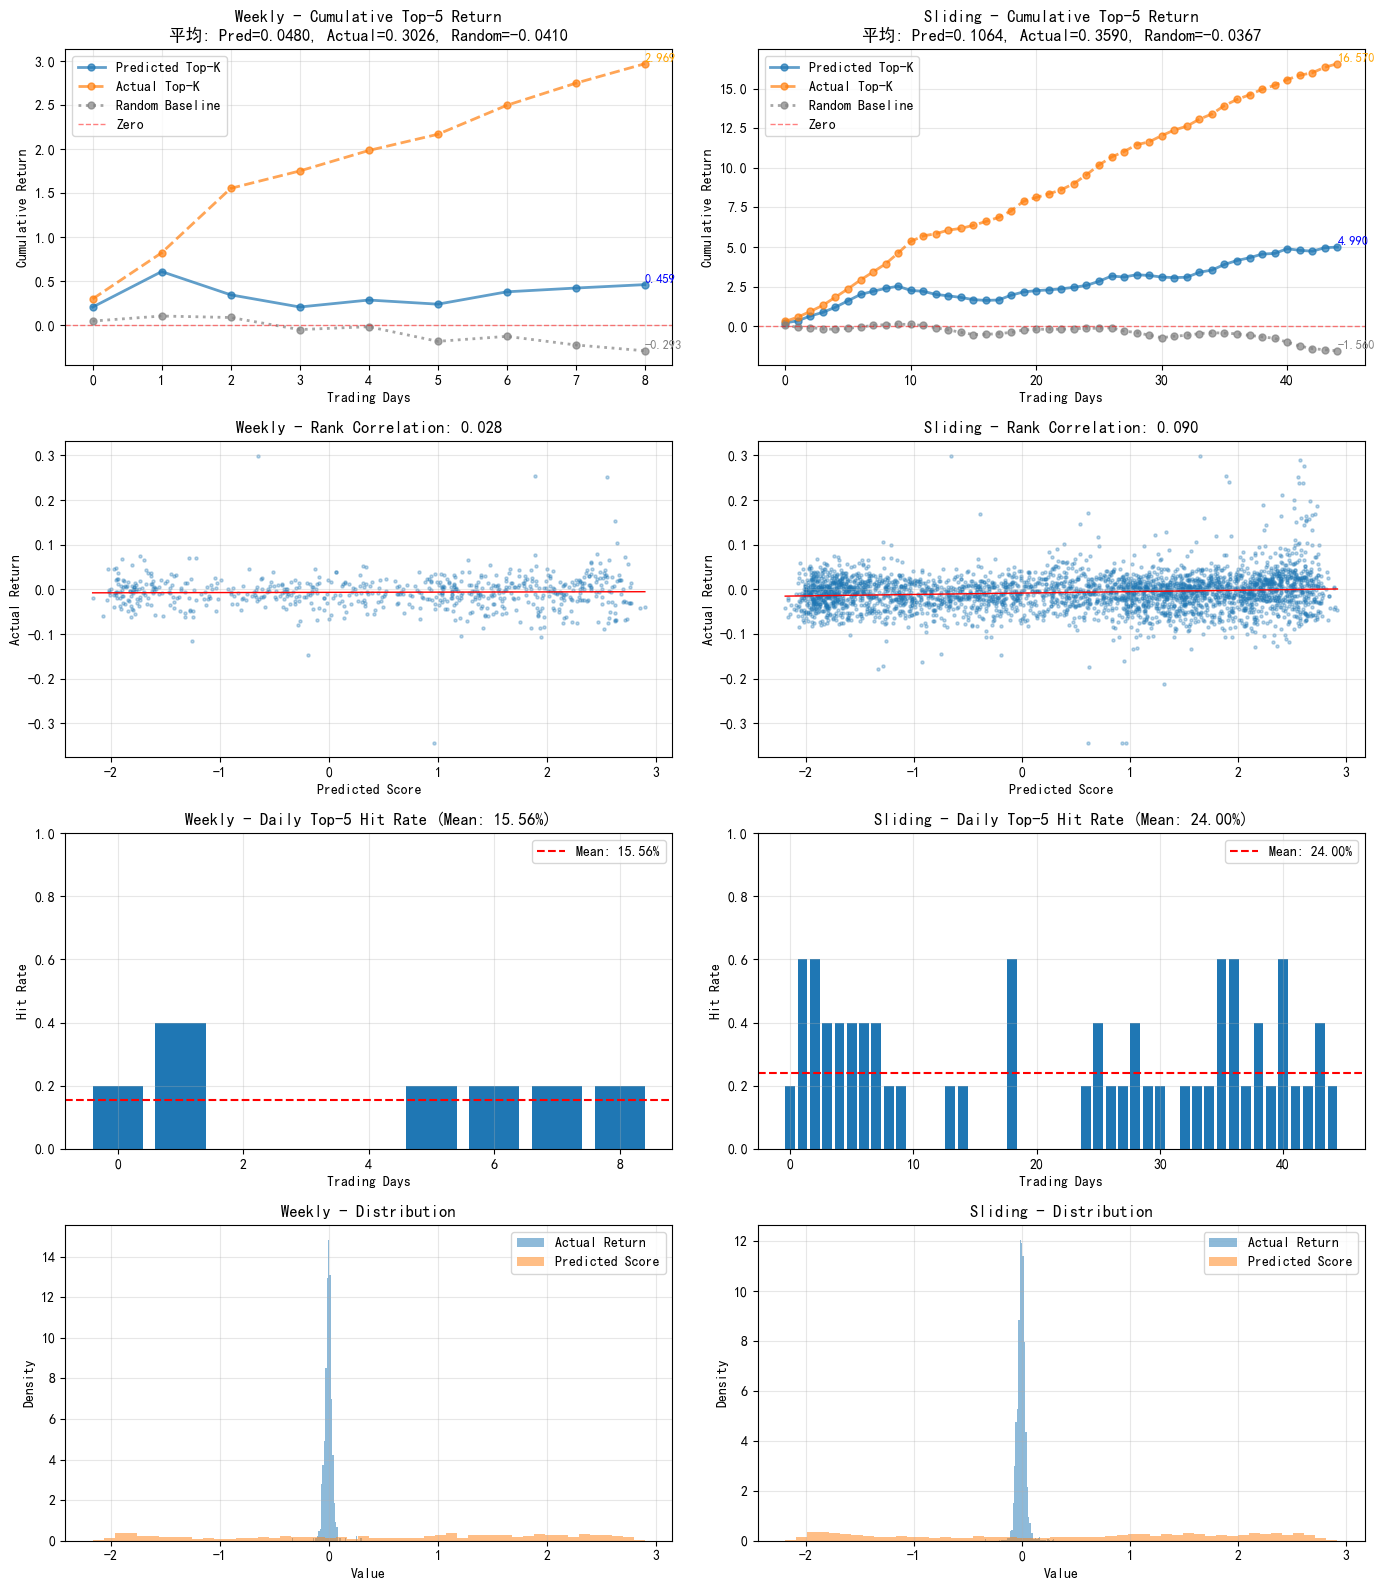

In [125]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans'] 
plt.rcParams['axes.unicode_minus'] = False 

# ========== 原有函数 ==========
def plot_metrics(ax, preds, targets, title, top_k=5, batch_size=4):
    """每日 top-k 预测收益累计（按batch平均，与训练时一致）"""
    daily_pred_topk = []
    daily_actual_topk = []
    daily_random_topk = []
    
    # 按batch平均
    num_batches = (len(preds) + batch_size - 1) // batch_size
    batch_pred_sums = []
    batch_actual_sums = []
    batch_random_sums = []
    
    for b in range(num_batches):
        start = b * batch_size
        end = min((b + 1) * batch_size, len(preds))
        
        batch_pred_topk = []
        batch_actual_topk = []
        batch_random_topk = []
        
        for i in range(start, end):
            top_k_idx = np.argsort(preds[i])[-top_k:]
            batch_pred_topk.append(np.sum(targets[i][top_k_idx]))
            batch_actual_topk.append(np.sum(np.sort(targets[i])[-top_k:]))
            batch_random_topk.append(top_k * np.mean(targets[i]))
        
        if batch_pred_topk:
            batch_pred_sums.append(np.mean(batch_pred_topk))
            batch_actual_sums.append(np.mean(batch_actual_topk))
            batch_random_sums.append(np.mean(batch_random_topk))
    
    if batch_pred_sums:
        avg_pred = np.mean(batch_pred_sums)
        avg_actual = np.mean(batch_actual_sums)
        avg_random = np.mean(batch_random_sums)
    else:
        avg_pred = avg_actual = avg_random = 0.0
    
    # 计算daily用于绘图
    for i in range(len(preds)):
        top_k_idx = np.argsort(preds[i])[-top_k:]
        daily_pred_topk.append(np.sum(targets[i][top_k_idx]))
        daily_actual_topk.append(np.sum(np.sort(targets[i])[-top_k:]))
        daily_random_topk.append(top_k * np.mean(targets[i]))
    
    # 计算累计收益
    cumsum_pred = np.cumsum(daily_pred_topk)
    cumsum_actual = np.cumsum(daily_actual_topk)
    cumsum_random = np.cumsum(daily_random_topk)
    
    # 绘制折线
    ax.plot(cumsum_pred, label="Predicted Top-K", alpha=0.7, markersize=5, marker="o", linewidth=2)
    ax.plot(cumsum_actual, label="Actual Top-K", alpha=0.7, markersize=5, marker="o", linestyle="--", linewidth=2)
    ax.plot(cumsum_random, label="Random Baseline", alpha=0.7, markersize=5, marker="o", linestyle=":", linewidth=2, color="gray")
    ax.axhline(y=0, color="r", linestyle="--", label="Zero", alpha=0.5, linewidth=1)
    
    # 在最后一个点标注最终值
    ax.text(len(cumsum_pred)-1, cumsum_pred[-1], 
            f'{cumsum_pred[-1]:.3f}', 
            ha='left', va='bottom', fontsize=9, fontweight='bold', color='blue')
    ax.text(len(cumsum_actual)-1, cumsum_actual[-1], 
            f'{cumsum_actual[-1]:.3f}', 
            ha='left', va='bottom', fontsize=9, fontweight='bold', color='orange')
    ax.text(len(cumsum_random)-1, cumsum_random[-1], 
            f'{cumsum_random[-1]:.3f}', 
            ha='left', va='bottom', fontsize=9, fontweight='bold', color='gray')
    
    ax.set_xlabel("Trading Days")
    ax.set_ylabel("Cumulative Return")
    ax.set_title(f"{title} - Cumulative Top-{top_k} Return"
                 f"平均: Pred={avg_pred:.4f}, Actual={avg_actual:.4f}, Random={avg_random:.4f}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax.set_xlabel("Trading Days")
    ax.set_ylabel("Cumulative Return")
    ax.set_title(f"{title} - Cumulative Top-{top_k} Return\n"
                 f"平均: Pred={avg_pred:.4f}, Actual={avg_actual:.4f}, Random={avg_random:.4f}")
    ax.legend()
    ax.grid(True, alpha=0.3)


def plot_correlation(ax, preds, targets, title):
    """预测排名 vs 实际排名相关性"""
    from scipy.stats import spearmanr
    all_corr = []
    for i in range(len(preds)):
        corr, _ = spearmanr(preds[i], targets[i])
        if not np.isnan(corr):
            all_corr.append(corr)
    corr = np.mean(all_corr) if all_corr else 0.0
    ax.scatter(preds.flatten(), targets.flatten(), alpha=0.3, s=5)
    from sklearn.linear_model import LinearRegression
    pred_flat = preds.flatten().reshape(-1, 1)
    target_flat = targets.flatten()
    valid_mask = ~(np.isnan(pred_flat).flatten() | np.isnan(target_flat))
    reg = LinearRegression()
    reg.fit(pred_flat[valid_mask], target_flat[valid_mask])
    x_line = np.linspace(pred_flat.min(), pred_flat.max(), 100).reshape(-1, 1)
    y_line = reg.predict(x_line)
    ax.plot(x_line, y_line, 'r-', linewidth=1)
    ax.set_xlabel("Predicted Score")
    ax.set_ylabel("Actual Return")
    ax.set_title(f"{title} - Rank Correlation: {corr:.3f}")
    ax.grid(True, alpha=0.3)


def plot_hit_rate(ax, preds, targets, title, top_k=5):
    """每日预测准确率"""
    accuracy = []
    for i in range(len(preds)):
        pred_topk = set(np.argsort(preds[i])[-top_k:])
        actual_topk = set(np.argsort(targets[i])[-top_k:])
        accuracy.append(len(pred_topk & actual_topk) / top_k)
    
    ax.bar(range(len(accuracy)), accuracy)
    ax.set_xlabel("Trading Days")
    ax.set_ylabel("Hit Rate")
    ax.set_ylim([0,1])
    ax.set_title(f"{title} - Daily Top-{top_k} Hit Rate (Mean: {np.mean(accuracy):.2%})")
    ax.axhline(y=np.mean(accuracy), color="r", linestyle="--", label=f"Mean: {np.mean(accuracy):.2%}")
    ax.legend()
    ax.grid(True, alpha=0.3)


def plot_distribution(ax, preds, targets, title):
    """预测收益分布"""
    ax.hist(targets.flatten(), bins=50, alpha=0.5, label="Actual Return", density=True)
    ax.hist(preds.flatten(), bins=50, alpha=0.5, label="Predicted Score", density=True)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.set_title(f"{title} - Distribution")
    ax.legend()
    ax.grid(True, alpha=0.3)

def plot_ranking_heatmap(ax, preds, targets, dates, title, top_k=5):
    """绘制真实排名热力图（包含平均排名列和平均收益率，底部添加每列平均）"""
    n_samples = min(len(preds), 20)
    
    rank_matrix = []
    return_matrix = []  # 存储收益率
    sample_labels = []
    avg_ranks = []
    avg_returns = []  # 存储平均收益率
    
    for i in range(n_samples):
        pred_top_idx = np.argsort(preds[i])[-top_k:][::-1]
        ranks = []
        returns = []
        for idx in pred_top_idx:
            rank = (targets[i] > targets[i][idx]).sum() + 1
            ret = targets[i][idx]
            ranks.append(rank)
            returns.append(ret)
        rank_matrix.append(ranks)
        return_matrix.append(returns)
        avg_ranks.append(np.mean(ranks))
        avg_returns.append(np.mean(returns))  # 平均收益率
        
        # 生成样本标签
        if dates is not None and i < len(dates):
            if hasattr(dates[i], 'strftime'):
                sample_labels.append(f"W{dates[i].isocalendar()[1]}")
            else:
                sample_labels.append(f"第{i+1}周")
        else:
            sample_labels.append(f"第{i+1}周")
    
    # 计算每列的平均排名和平均收益率
    col_avg_ranks = []
    col_avg_returns = []
    for j in range(top_k):
        col_ranks = [rank_matrix[i][j] for i in range(n_samples)]
        col_returns = [return_matrix[i][j] for i in range(n_samples)]
        col_avg_ranks.append(np.mean(col_ranks))
        col_avg_returns.append(np.mean(col_returns))
    
    # 计算平均列的平均
    overall_avg_rank = np.mean(col_avg_ranks)
    overall_avg_return = np.mean(col_avg_returns)
    
    # 创建带收益率的热力图数据（用排名决定颜色）
    # 扩展矩阵：添加平均列，再添加一行底部平均
    rank_matrix_extended = []
    for i in range(n_samples):
        row = rank_matrix[i] + [avg_ranks[i]]
        rank_matrix_extended.append(row)
    
    # 添加底部行
    bottom_row = col_avg_ranks + [overall_avg_rank]
    rank_matrix_extended.append(bottom_row)
    
    rank_matrix_extended = np.array(rank_matrix_extended)
    
    im = ax.imshow(rank_matrix_extended, cmap='RdYlGn_r', aspect='auto', 
                   vmin=1, vmax=len(targets[0]))
    
    # 添加数值标签
    for i in range(n_samples):
        for j in range(top_k):
            rank = rank_matrix[i][j]
            ret = return_matrix[i][j]
            text = f"{rank}({ret*100:.1f}%)"
            color = "white" if rank > 25 else "black"
            ax.text(j, i, text, ha="center", va="center", 
                   color=color, fontsize=7, fontweight='normal')
        
        # 平均排名列
        avg_rank = avg_ranks[i]
        avg_ret = avg_returns[i]
        text_avg = f"{avg_rank:.1f}({avg_ret*100:.1f}%)"
        color = "white" if avg_rank > 25 else "black"
        ax.text(top_k, i, text_avg, ha="center", va="center", 
               color=color, fontsize=7, fontweight='bold')
    
    # 底部行：每列的平均排名和平均收益率
    for j in range(top_k):
        avg_rank = col_avg_ranks[j]
        avg_ret = col_avg_returns[j]
        text = f"{avg_rank:.1f}({avg_ret*100:.1f}%)"
        color = "white" if avg_rank > 25 else "black"
        ax.text(j, n_samples, text, ha="center", va="center", 
               color=color, fontsize=7, fontweight='bold', 
               bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    # 底部平均列
    text_overall = f"{overall_avg_rank:.1f}({overall_avg_return*100:.1f}%)"
    ax.text(top_k, n_samples, text_overall, ha="center", va="center", 
           color="black", fontsize=7, fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='gold', alpha=0.8))
    
    ax.set_xlabel('预测排名位置')
    ax.set_ylabel('周次')
    ax.set_title(f'{title} - 真实排名热力图')
    
    # 设置x轴标签
    x_labels = [f'{i+1}名' for i in range(top_k)] + ['平均']
    ax.set_xticks(range(top_k + 1))
    ax.set_xticklabels(x_labels)
    
    # 设置y轴标签（包括底部行）
    y_labels = sample_labels + ['整体平均']
    ax.set_yticks(range(n_samples + 1))
    ax.set_yticklabels(y_labels, fontsize=8)
    
    plt.colorbar(im, ax=ax, label='真实排名')


def plot_ranking_trend(ax, preds, targets, dates, title, top_k=5):
    """绘制排名趋势图"""
    n_samples = min(len(preds), 30)
    
    for i in range(n_samples):
        pred_top_idx = np.argsort(preds[i])[-top_k:][::-1]
        ranks = []
        for idx in pred_top_idx:
            rank = (targets[i] > targets[i][idx]).sum() + 1
            ranks.append(rank)
        
        avg_rank = np.mean(ranks)
        if avg_rank <= 10:
            color = '#2ecc71'
        elif avg_rank <= 20:
            color = '#f39c12'
        else:
            color = '#e74c3c'
        
        # 生成标签
        if dates is not None and i < len(dates):
            if hasattr(dates[i], 'strftime'):
                label = f"W{dates[i].isocalendar()[1]}"
            else:
                label = f"第{i+1}周"
        else:
            label = f"第{i+1}周"
        
        ax.plot(range(1, top_k+1), ranks, 'o-', linewidth=1.5, markersize=4,
                color=color, alpha=0.6, label=label if i < 5 else "")
    
    ax.axhline(y=10, color='#2ecc71', linestyle='--', alpha=0.7, linewidth=2, label='Top10')
    ax.axhline(y=20, color='#f39c12', linestyle='--', alpha=0.7, linewidth=2, label='Top20')
    ax.axhline(y=30, color='#e74c3c', linestyle='--', alpha=0.7, linewidth=2, label='Top30')
    
    ax.set_xlabel('预测排名位置')
    ax.set_ylabel('真实排名')
    ax.set_title(f'{title} - 排名趋势图')
    ax.set_xticks(range(1, top_k+1))
    ax.set_xticklabels([f'{i+1}名' for i in range(top_k)])
    ax.set_ylim(0, 45)
    ax.invert_yaxis()
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)


# ========== 主可视化代码 ==========
n_weekly = len(preds_weekly)
n_sliding = len(preds_sliding)
show_ranking = n_weekly <= 30 and n_sliding <= 30

# 如果没有日期数据，传入 None
weekly_dates = None
sliding_dates = None

if show_ranking:
    fig, axes = plt.subplots(5, 2, figsize=(14, 20))  # 5行2列 
    
    # Weekly 验证集
    plot_metrics(axes[0, 0], preds_weekly, targets_weekly, "Weekly")
    plot_correlation(axes[1, 0], preds_weekly, targets_weekly, "Weekly")
    plot_hit_rate(axes[2, 0], preds_weekly, targets_weekly, "Weekly")
    plot_ranking_trend(axes[3, 0], preds_weekly, targets_weekly, weekly_dates, "Weekly")
    plot_ranking_heatmap(axes[4, 0], preds_weekly, targets_weekly, weekly_dates, "Weekly")
    
    # Sliding 验证集
    plot_metrics(axes[0, 1], preds_sliding, targets_sliding, "Sliding")
    plot_correlation(axes[1, 1], preds_sliding, targets_sliding, "Sliding")
    plot_hit_rate(axes[2, 1], preds_sliding, targets_sliding, "Sliding")
    plot_ranking_trend(axes[3, 1], preds_sliding, targets_sliding, sliding_dates, "Sliding")
    plot_ranking_heatmap(axes[4, 1], preds_sliding, targets_sliding, sliding_dates, "Sliding")
    
else:
    # 样本太多时使用简化版
    fig, axes = plt.subplots(4, 2, figsize=(14, 16))
    
    plot_metrics(axes[0, 0], preds_weekly, targets_weekly, "Weekly")
    plot_correlation(axes[1, 0], preds_weekly, targets_weekly, "Weekly")
    plot_hit_rate(axes[2, 0], preds_weekly, targets_weekly, "Weekly")
    plot_distribution(axes[3, 0], preds_weekly, targets_weekly, "Weekly")
    
    plot_metrics(axes[0, 1], preds_sliding, targets_sliding, "Sliding")
    plot_correlation(axes[1, 1], preds_sliding, targets_sliding, "Sliding")
    plot_hit_rate(axes[2, 1], preds_sliding, targets_sliding, "Sliding")
    plot_distribution(axes[3, 1], preds_sliding, targets_sliding, "Sliding")
    
    print(f"样本数较多 (Weekly:{n_weekly}, Sliding:{n_sliding})，已跳过排名详细图")

plt.tight_layout()
plt.show()

## 模型融合 

In [126]:
# ========== 模型融合分析 ==========

# 加载 targets (使用第一个模型的targets，应该相同)
first_exp_dir = os.path.join(combined_df.iloc[0]['search_dir'], combined_df.iloc[0]['exp_dir'])
targets_weekly = np.load(os.path.join(first_exp_dir, "targets_weekly.npy"))
targets_sliding = np.load(os.path.join(first_exp_dir, "targets_sliding.npy"))

# 选择最优的n个模型进行融合
select_n = 5
# 方法1: 按 weekly_pred_return_sum 选 top select_n
metric_for_selection = "weekly_score"
top_df = best_models.sort_values(metric_for_selection, ascending=False).head(select_n)
print(f"Top {select_n} 模型 (按 {metric_for_selection}):")
display(top_df[base_cols + [metric_for_selection]])

# 加载3个模型的预测
ensemble_preds_weekly = []
ensemble_preds_sliding = []

for idx, row in top_df.iterrows():
    exp_dir = os.path.join(row['search_dir'], row['exp_dir'])
    epoch = row['epoch']
    
    pred_weekly = np.load(os.path.join(exp_dir, f"preds_weekly_epoch{epoch}.npy"))
    pred_sliding = np.load(os.path.join(exp_dir, f"preds_sliding_epoch{epoch}.npy"))
    
    ensemble_preds_weekly.append(pred_weekly)
    ensemble_preds_sliding.append(pred_sliding)
    # 检查预测是否有 -1e9 (masked values)
    if -1e9 in pred_weekly or -1e8 in pred_weekly:
        print(f"  WARNING: Found masked values in predictions!")

# 简单平均融合 (直接融合排序分数)
ensemble_weekly = np.mean(ensemble_preds_weekly, axis=0)
ensemble_sliding = np.mean(ensemble_preds_sliding, axis=0)

# 调试: 检查各模型预测
print("=== 预测统计 ===")
for j, (pred, name) in enumerate(zip(ensemble_preds_weekly, [f"Model {j+1}" for j in range(3)])):
    print(f"{name}: mean={pred.mean():.4f}, std={pred.std():.4f}, min={pred.min():.4f}, max={pred.max():.4f}")
print(f"融合后: mean={ensemble_weekly.mean():.4f}, std={ensemble_weekly.std():.4f}")
# 检查各模型预测的相关系数

from scipy.stats import spearmanr
print("\n=== 模型预测相关性 ===")
for j in range(len(ensemble_preds_weekly)):
    for k in range(j+1, len(ensemble_preds_weekly)):
        corr, _ = spearmanr(ensemble_preds_weekly[j].flatten(), ensemble_preds_weekly[k].flatten())
        print(f"Model {j+1} vs Model {k+1}: corr={corr:.4f}")




Top 5 模型 (按 weekly_score):


,model_type,exp_dir,epoch,weekly_score
993,itransformer,exp_63,4,0.326067
994,itransformer,exp_63,5,0.317712
1414,itransformer,exp_64,5,0.315613
547,itransformer,exp_68,8,0.309224
2493,itransformer,exp_67,4,0.301077


=== 预测统计 ===
Model 1: mean=1.7154, std=0.8880, min=-0.7387, max=3.3354
Model 2: mean=1.4088, std=1.1390, min=-1.8910, max=3.3319
Model 3: mean=0.5469, std=1.4927, min=-2.1679, max=2.8978
融合后: mean=1.2189, std=1.1898

=== 模型预测相关性 ===
Model 1 vs Model 2: corr=0.8942
Model 1 vs Model 3: corr=0.6896
Model 1 vs Model 4: corr=0.4543
Model 1 vs Model 5: corr=0.8151
Model 2 vs Model 3: corr=0.8579
Model 2 vs Model 4: corr=0.6151
Model 2 vs Model 5: corr=0.8562
Model 3 vs Model 4: corr=0.6746
Model 3 vs Model 5: corr=0.7789
Model 4 vs Model 5: corr=0.6750


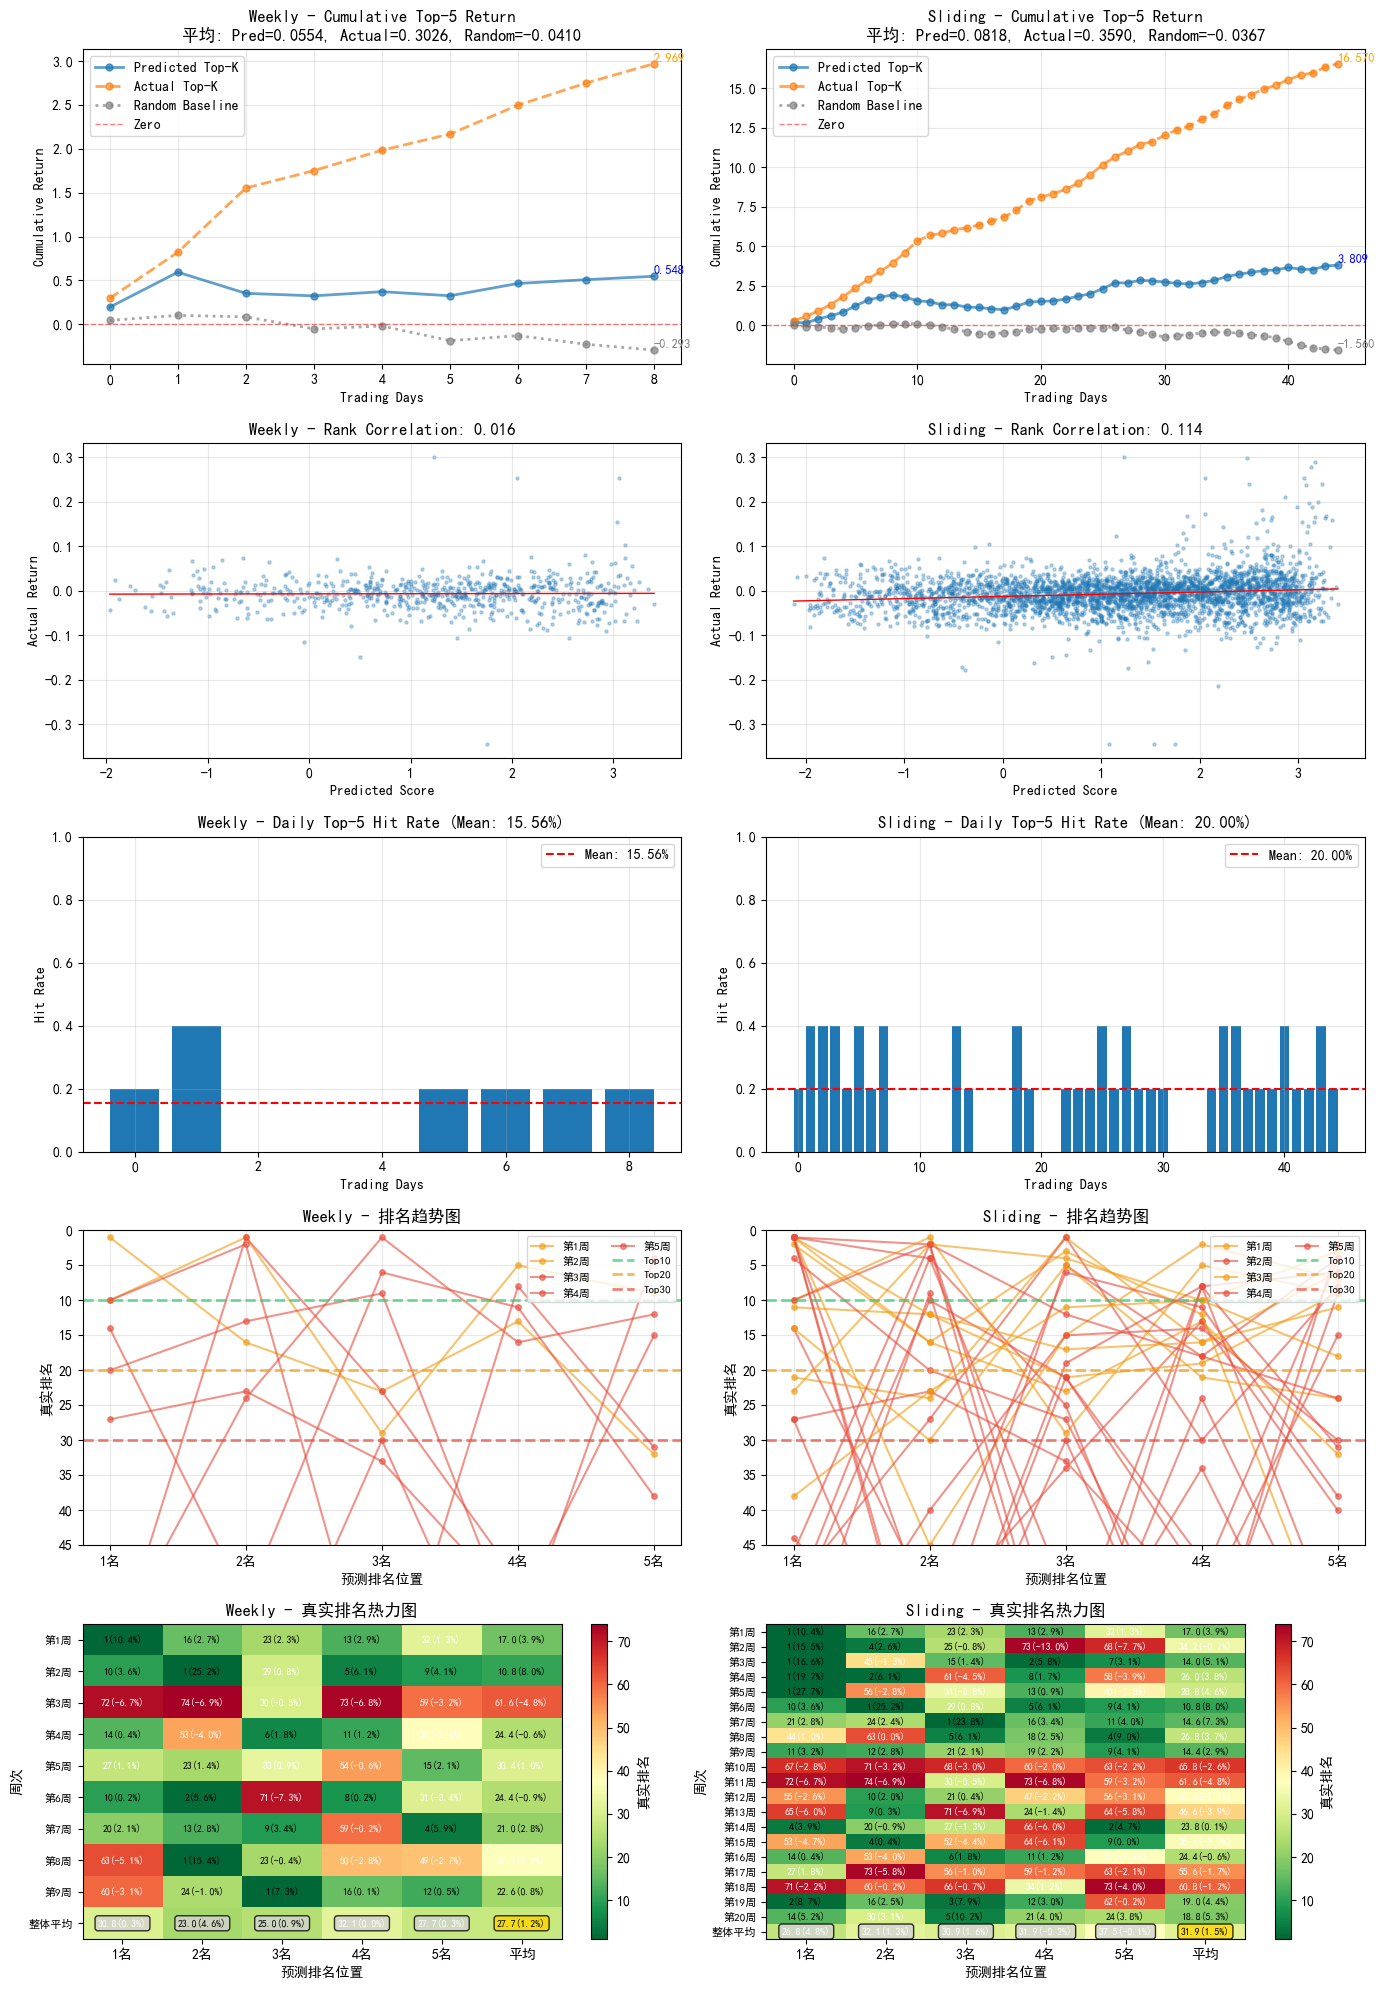

In [127]:
fig, axes = plt.subplots(5, 2, figsize=(14, 20))  # 5行2列 

# Weekly 验证集
plot_metrics(axes[0, 0], ensemble_weekly, targets_weekly, "Weekly")
plot_correlation(axes[1, 0], ensemble_weekly, targets_weekly, "Weekly")
plot_hit_rate(axes[2, 0], ensemble_weekly, targets_weekly, "Weekly")
plot_ranking_trend(axes[3, 0], ensemble_weekly, targets_weekly, weekly_dates, "Weekly")
plot_ranking_heatmap(axes[4, 0], ensemble_weekly, targets_weekly, weekly_dates, "Weekly")

# Sliding 验证集
plot_metrics(axes[0, 1], ensemble_sliding, targets_sliding, "Sliding")
plot_correlation(axes[1, 1], ensemble_sliding, targets_sliding, "Sliding")
plot_hit_rate(axes[2, 1], ensemble_sliding, targets_sliding, "Sliding")
plot_ranking_trend(axes[3, 1], ensemble_sliding, targets_sliding, sliding_dates, "Sliding")
plot_ranking_heatmap(axes[4, 1], ensemble_sliding, targets_sliding, sliding_dates, "Sliding")
plt.tight_layout()

原始权重: [0.049684 0.054188 0.047991 0.053435 0.040146]
排名权重: [0.33333333 0.26666667 0.2        0.13333333 0.06666667]

=== 融合结果对比 ===
简单平均: mean=1.218945, std=1.189800
排名加权: mean=1.226141, std=1.103391
差异: 0.692008


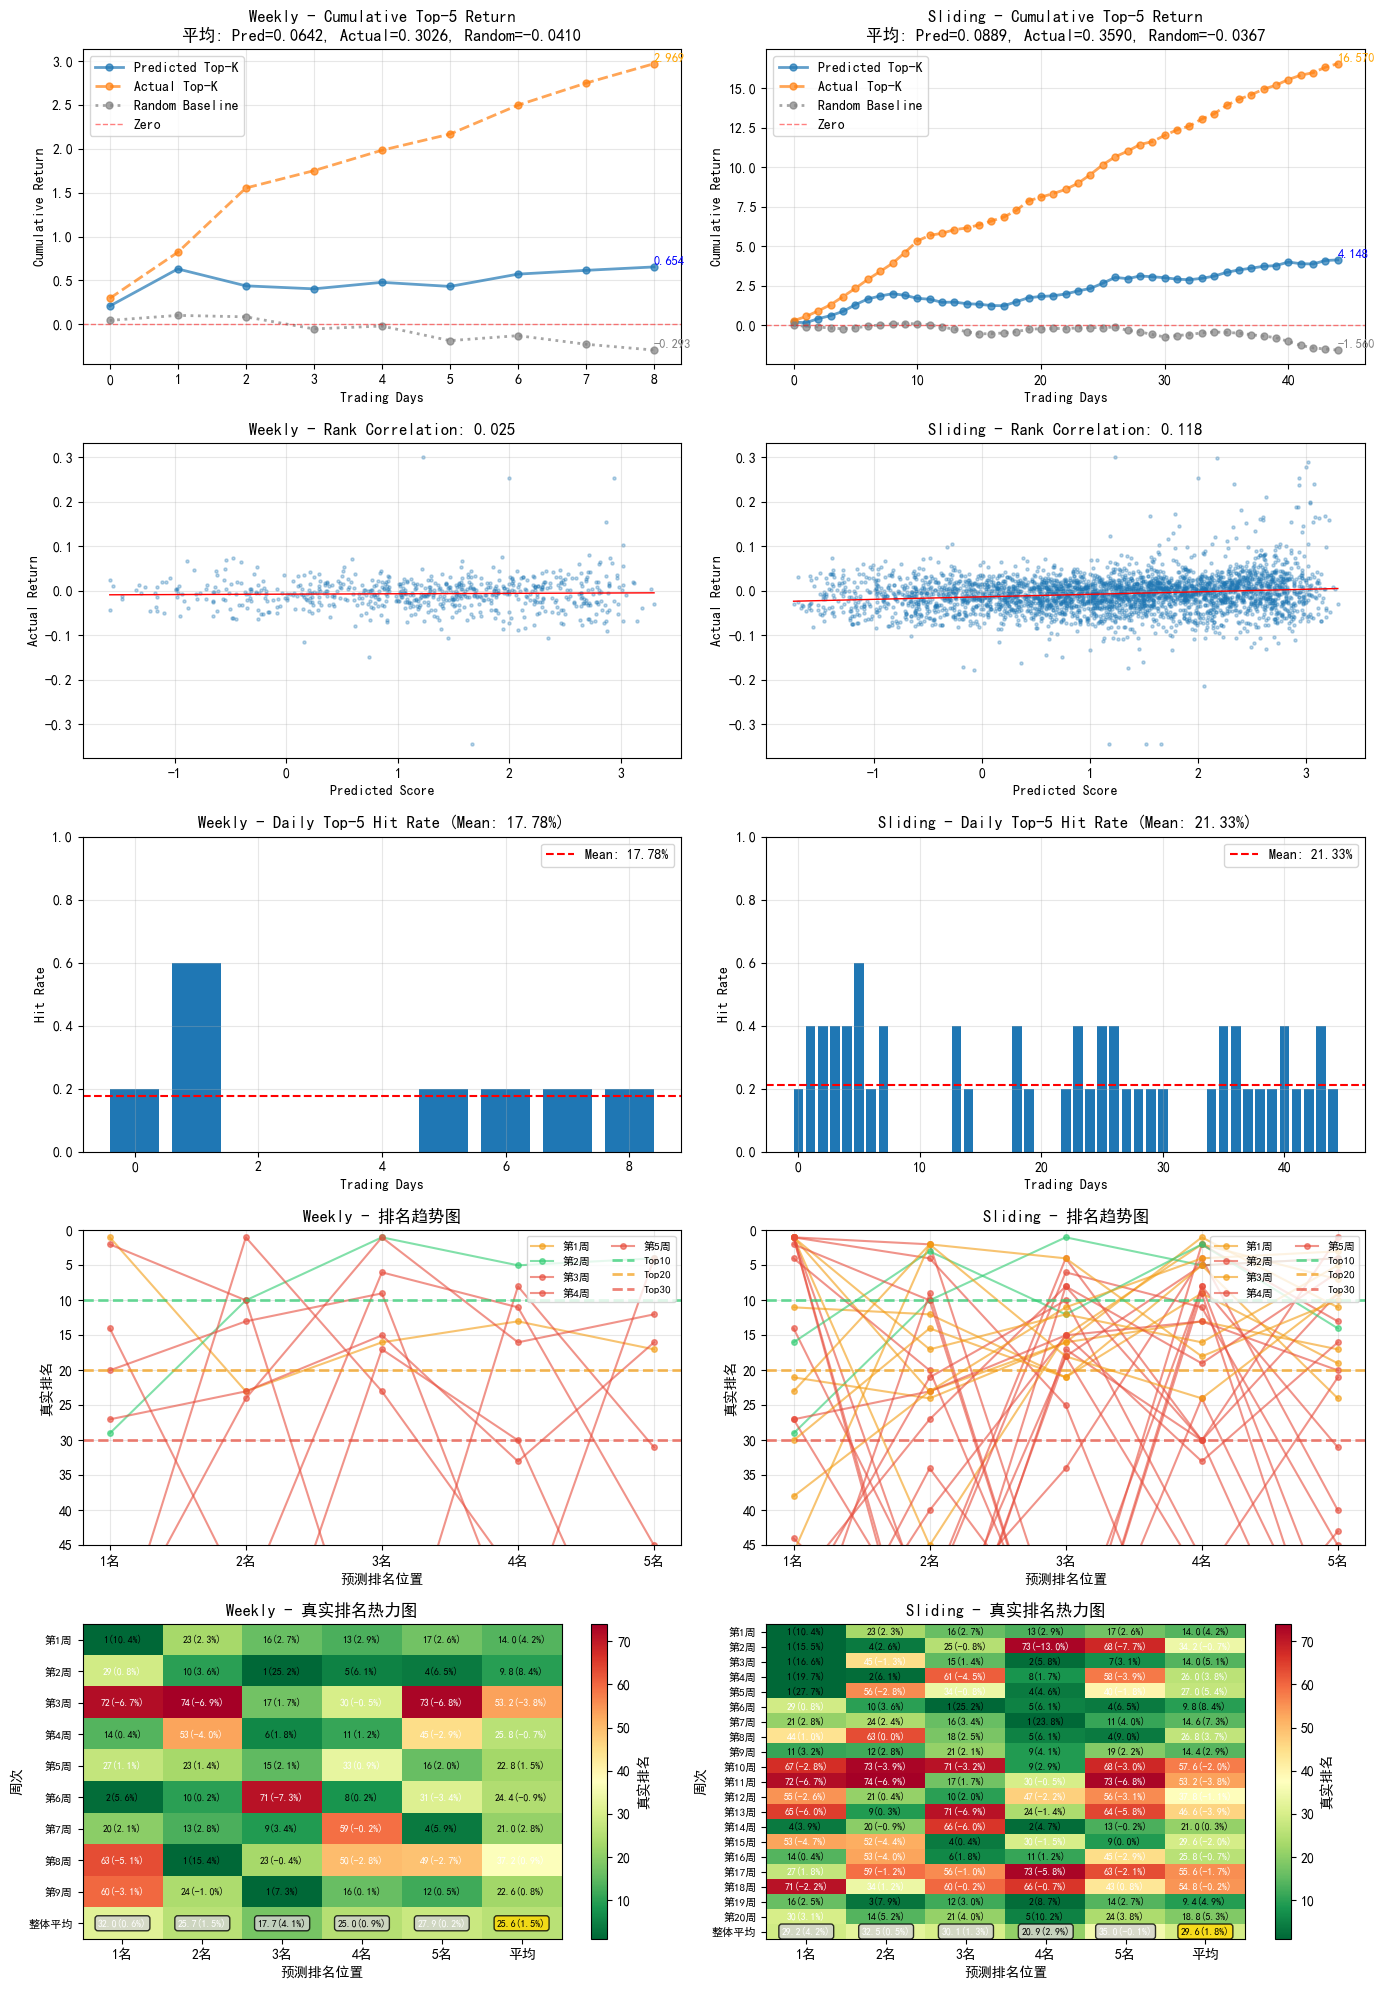

In [128]:
# 加权融合 (使用排名权重，避免负值问题)


# 方法2: 使用排名作为权重 (更稳健)
rank_weights = np.arange(1, len(ensemble_preds_weekly) + 1)[::-1]  # [3, 2, 1]
rank_weights = rank_weights / rank_weights.sum()
ensemble_weekly_rank = np.average(ensemble_preds_weekly, axis=0, weights=rank_weights)
ensemble_sliding_rank = np.average(ensemble_preds_sliding, axis=0, weights=rank_weights)

print(f"原始权重: {top_df['weekly_pred_return_sum'].values}")
print(f"排名权重: {rank_weights}")

# 调试: 检查不同融合方法的差异
print("\n=== 融合结果对比 ===")
print(f"简单平均: mean={ensemble_weekly.mean():.6f}, std={ensemble_weekly.std():.6f}")
print(f"排名加权: mean={ensemble_weekly_rank.mean():.6f}, std={ensemble_weekly_rank.std():.6f}")
print(f"差异: {np.abs(ensemble_weekly - ensemble_weekly_rank).max():.6f}")

fig, axes = plt.subplots(5, 2, figsize=(14, 20))  # 5行2列 

# Weekly 验证集
plot_metrics(axes[0, 0], ensemble_weekly_rank, targets_weekly, "Weekly")
plot_correlation(axes[1, 0], ensemble_weekly_rank, targets_weekly, "Weekly")
plot_hit_rate(axes[2, 0], ensemble_weekly_rank, targets_weekly, "Weekly")
plot_ranking_trend(axes[3, 0], ensemble_weekly_rank, targets_weekly, weekly_dates, "Weekly")
plot_ranking_heatmap(axes[4, 0], ensemble_weekly_rank, targets_weekly, weekly_dates, "Weekly")

# Sliding 验证集
plot_metrics(axes[0, 1], ensemble_sliding_rank, targets_sliding, "Sliding")
plot_correlation(axes[1, 1], ensemble_sliding_rank, targets_sliding, "Sliding")
plot_hit_rate(axes[2, 1], ensemble_sliding_rank, targets_sliding, "Sliding")
plot_ranking_trend(axes[3, 1], ensemble_sliding_rank, targets_sliding, sliding_dates, "Sliding")
plot_ranking_heatmap(axes[4, 1], ensemble_sliding_rank, targets_sliding, sliding_dates, "Sliding")
plt.tight_layout()